In [1]:
import torch
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import argparse
import importlib
import random
import torch.nn.functional as F
import torchvision
import numpy as np
from math import *
import matplotlib.pyplot as plt
from torch.autograd import Variable
from IPython import display
import torch.utils.data as Data
import torch.nn as nn
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import LinearLocator, FormatStrFormatter
# %matplotlib notebook
from matplotlib import cm
from scipy.linalg import block_diag
import datetime
from torch.nn.utils import *
import Network_FDD as FDD

D:\Compiler\anaconda3\envs\ofdm_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')
if not os.path.exists('results'):
    os.makedirs('results')
DATA_DIR = "data"

In [3]:
def train(Nc, N, Nt, B, Nr, L, SNR_dB, K, EPOCH, BATCH_SIZE):
    shoulian = np.zeros(EPOCH)
    snr = 10**(SNR_dB/10) / K
    parm_set = [Nc, Nt, Nr, snr, B, K]

    H_train = torch.load(os.path.join(DATA_DIR, f'H_train_N{N}.pt'))
    H_test = torch.load(os.path.join(DATA_DIR, f'H_test_N{N}.pt'))
    # H_train_1 = torch.load('data/H_train_UPA' + str(N) + 'Lp_1.pt')[:, 0:K, :, :]
    # H_train_2 = torch.load('data/H_train_UPA' + str(N) + 'Lp_2.pt')[:, 0:K, :, :]
    # H_train = torch.cat([H_train_1, H_train_2], 0)
    # H_test = torch.load('data/H_test_UPA' + str(N) + 'Lp.pt')[:, 0:K, :, :]

    net_US = FDD.DNN_US_RF_OFDM(parm_set).cuda()
    net_BS = FDD.DNN_BS_hyb_OFDM(parm_set).cuda()


    optimizer_US = torch.optim.Adam(net_US.parameters(), lr=0.001)
    scheduler_US = torch.optim.lr_scheduler.MultiStepLR(optimizer_US, milestones=[100, 150], gamma=0.6)
    optimizer_BS = torch.optim.Adam(net_BS.parameters(), lr=0.001)
    scheduler_BS = torch.optim.lr_scheduler.MultiStepLR(optimizer_BS, milestones=[100, 150], gamma=0.6)
    loss_func1 = FDD.MyLoss_OFDM().cuda()

    loader_train = Data.DataLoader(Data.TensorDataset(H_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    loader_test = Data.DataLoader(Data.TensorDataset(H_test), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    train_losses, test_losses = [], []
    best_test_se = 0
    plt.ion()  # 开启交互模式

    start = datetime.datetime.now()
    for epoch in range(EPOCH):
        train_SE, num_train = 0, 0
        test_SE, num_test = 0, 0

        for step, [b_x] in enumerate(loader_train):
            num_train += 1
            net_US.train()
            net_BS.train()
            b_x = b_x.cuda()
            num = b_x.shape[0]
            out1 = torch.zeros([num, B * K]).cuda()
            for i in range(K):
                out1[:, i * B:(i * B + B)] = net_US(b_x[:, i, :, :], parm_set)
            out2 = net_BS(out1, parm_set)
            loss = loss_func1(b_x, out2, parm_set)
            train_SE -= loss.item()

            optimizer_US.zero_grad()
            optimizer_BS.zero_grad()
            loss.backward()
            optimizer_US.step()
            optimizer_BS.step()

        train_SE /= num_train
        scheduler_US.step()
        scheduler_BS.step()

        net_US.eval()
        net_BS.eval()
        with torch.no_grad():
            for step, [b_x] in enumerate(loader_test):
                num_test += 1
                b_x = b_x.cuda()
                num = b_x.shape[0]
                out1 = torch.zeros([num, B * K]).cuda()
                for i in range(K):
                    out1[:, i * B:(i * B + B)] = net_US(b_x[:, i, :, :], parm_set)
                out2 = net_BS(out1, parm_set)
                loss = loss_func1(b_x, out2, parm_set)
                test_SE -= loss.item()

        test_SE /= num_test
        time_elapsed = datetime.datetime.now() - start
        print(f'Epoch: {epoch} | Time: {time_elapsed} | Train SE: {train_SE:.3f} | Test SE: {test_SE:.3f}')
        start = datetime.datetime.now()

        train_losses.append(train_SE)
        test_losses.append(test_SE)

        if epoch > 0 and epoch % 10 == 0:
            plt.clf()
            plt.plot(train_losses, label='Train SE')
            plt.plot(test_losses, label='Test SE')
            plt.xlabel('Epoch')
            plt.ylabel('Spectral Efficiency')
            plt.title(f'Training Progress (B={B}, N={N}) - Epoch {epoch}')
            plt.legend()
            plt.grid(True)
            plt.savefig(f'results/progress_snapshot_{B}B{N}Lp{L}L{K}K_epoch{epoch}.png')
            plt.pause(0.1)

        if test_SE > best_test_se:
            best_test_se = test_SE
            torch.save(net_US, f'saved_models/net_US_{B}B{N}Lp{L}L{K}K.pth')
            torch.save(net_BS, f'saved_models/net_BS_{B}B{N}Lp{L}L{K}K.pth')
            print(f'New best model saved with Test SE: {best_test_se:.4f}')

        shoulian[epoch] = test_SE

    plt.ioff()
    plt.clf()
    plt.plot(train_losses, label='Train SE')
    plt.plot(test_losses, label='Test SE')
    plt.axhline(y=best_test_se, color='r', linestyle='--', label=f'Best Test SE: {best_test_se:.4f}')
    plt.xlabel('Epoch')
    plt.ylabel('Spectral Efficiency')
    plt.title(f'Final Training Progress (B={B}, N={N})')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'results/final_progress_{B}B{N}Lp{L}L{K}K.png')
    plt.show()
    print(f'The best SE is: {max(test_losses):.3f}')
    print(shoulian)

In [4]:
Nc = 32 #number of subcarriers
N = 1   # Number of paths
Nt = 64 # Number of Antennas at the BS
Nr = 1  # Number of Antennas at the UE
# B = 30

L = 8   # number of pilot OFDM symbols
SNR_dB = 10  # SNR
K = 2   # number of UEs
snr =  10**(SNR_dB/10)/K

BATCH_SIZE = 512
EPOCH = 180


Epoch: 0 | Time: 0:01:09.608270 | Train SE: 6.614 | Test SE: 8.106
New best model saved with Test SE: 8.1063
Epoch: 1 | Time: 0:01:07.739187 | Train SE: 8.599 | Test SE: 9.125
New best model saved with Test SE: 9.1253
Epoch: 2 | Time: 0:01:08.694105 | Train SE: 9.688 | Test SE: 10.311
New best model saved with Test SE: 10.3105
Epoch: 3 | Time: 0:01:08.352672 | Train SE: 10.598 | Test SE: 10.898
New best model saved with Test SE: 10.8980
Epoch: 4 | Time: 0:01:08.279302 | Train SE: 11.043 | Test SE: 11.330
New best model saved with Test SE: 11.3299
Epoch: 5 | Time: 0:01:08.671708 | Train SE: 11.403 | Test SE: 11.621
New best model saved with Test SE: 11.6206
Epoch: 6 | Time: 0:01:09.194443 | Train SE: 11.618 | Test SE: 11.804
New best model saved with Test SE: 11.8036
Epoch: 7 | Time: 0:01:09.757121 | Train SE: 11.837 | Test SE: 11.960
New best model saved with Test SE: 11.9600
Epoch: 8 | Time: 0:01:10.148634 | Train SE: 11.947 | Test SE: 12.052
New best model saved with Test SE: 12.0519

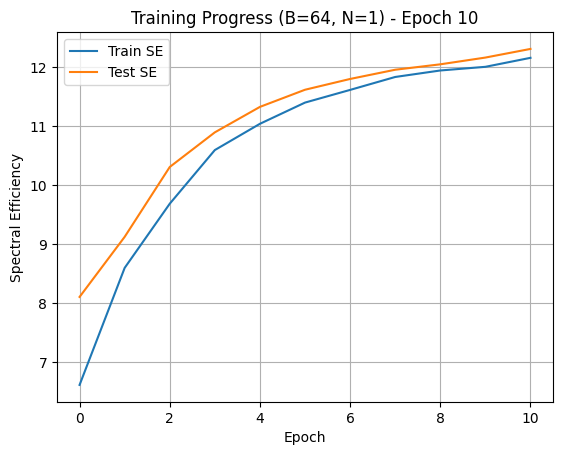

New best model saved with Test SE: 12.3130
Epoch: 11 | Time: 0:01:10.571580 | Train SE: 12.270 | Test SE: 12.316
New best model saved with Test SE: 12.3157
Epoch: 12 | Time: 0:01:10.012890 | Train SE: 11.946 | Test SE: 11.703
Epoch: 13 | Time: 0:01:09.239306 | Train SE: 11.831 | Test SE: 12.103
Epoch: 14 | Time: 0:01:09.265304 | Train SE: 12.053 | Test SE: 12.171
Epoch: 15 | Time: 0:01:09.383866 | Train SE: 12.165 | Test SE: 12.340
New best model saved with Test SE: 12.3400
Epoch: 16 | Time: 0:01:09.853965 | Train SE: 12.293 | Test SE: 12.398
New best model saved with Test SE: 12.3982
Epoch: 17 | Time: 0:01:09.866155 | Train SE: 12.375 | Test SE: 12.472
New best model saved with Test SE: 12.4718
Epoch: 18 | Time: 0:01:09.902730 | Train SE: 12.380 | Test SE: 12.485
New best model saved with Test SE: 12.4854
Epoch: 19 | Time: 0:01:09.848373 | Train SE: 12.441 | Test SE: 12.577
New best model saved with Test SE: 12.5772
Epoch: 20 | Time: 0:01:09.650538 | Train SE: 12.547 | Test SE: 12.672

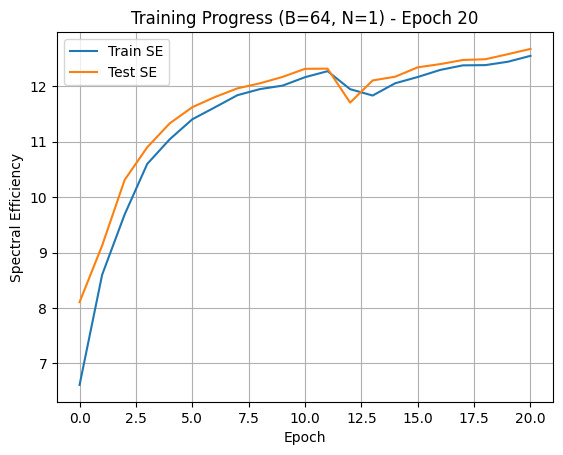

New best model saved with Test SE: 12.6716
Epoch: 21 | Time: 0:01:09.746030 | Train SE: 12.585 | Test SE: 12.674
New best model saved with Test SE: 12.6738
Epoch: 22 | Time: 0:01:10.009903 | Train SE: 12.616 | Test SE: 12.666
Epoch: 23 | Time: 0:01:10.527499 | Train SE: 12.604 | Test SE: 12.720
New best model saved with Test SE: 12.7203
Epoch: 24 | Time: 0:01:10.093304 | Train SE: 12.659 | Test SE: 12.758
New best model saved with Test SE: 12.7581
Epoch: 25 | Time: 0:01:09.468861 | Train SE: 12.656 | Test SE: 12.738
Epoch: 26 | Time: 0:01:09.814926 | Train SE: 12.655 | Test SE: 12.760
New best model saved with Test SE: 12.7604
Epoch: 27 | Time: 0:01:08.669986 | Train SE: 12.556 | Test SE: 12.572
Epoch: 28 | Time: 0:01:08.496359 | Train SE: 12.590 | Test SE: 12.683
Epoch: 29 | Time: 0:01:08.679395 | Train SE: 12.666 | Test SE: 12.728
Epoch: 30 | Time: 0:01:09.287671 | Train SE: 12.658 | Test SE: 12.776


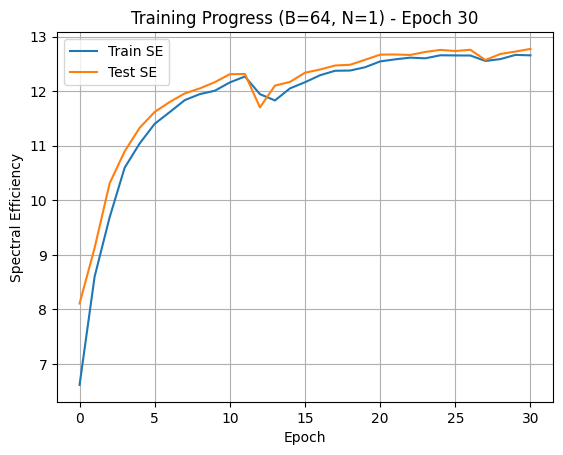

New best model saved with Test SE: 12.7760
Epoch: 31 | Time: 0:01:09.280390 | Train SE: 12.734 | Test SE: 12.831
New best model saved with Test SE: 12.8311
Epoch: 32 | Time: 0:01:09.017023 | Train SE: 12.696 | Test SE: 12.743
Epoch: 33 | Time: 0:01:09.137066 | Train SE: 12.722 | Test SE: 12.817
Epoch: 34 | Time: 0:01:09.218169 | Train SE: 12.721 | Test SE: 12.737
Epoch: 35 | Time: 0:01:08.515366 | Train SE: 12.731 | Test SE: 12.890
New best model saved with Test SE: 12.8903
Epoch: 36 | Time: 0:01:09.656034 | Train SE: 12.770 | Test SE: 12.817
Epoch: 37 | Time: 0:01:09.078769 | Train SE: 12.762 | Test SE: 12.850
Epoch: 38 | Time: 0:01:11.103960 | Train SE: 12.690 | Test SE: 12.737
Epoch: 39 | Time: 0:01:10.248978 | Train SE: 12.684 | Test SE: 12.757
Epoch: 40 | Time: 0:01:10.554461 | Train SE: 12.557 | Test SE: 12.678


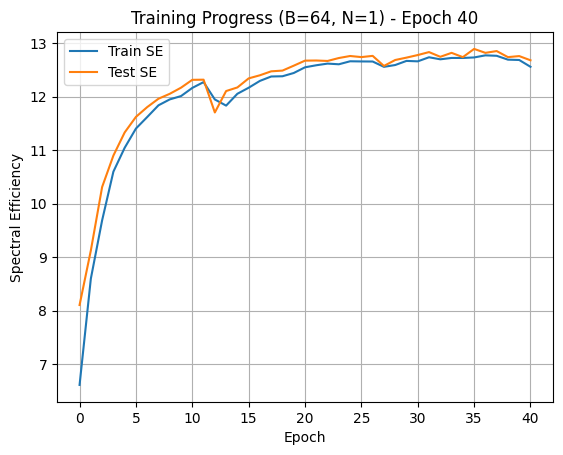

Epoch: 41 | Time: 0:01:10.756338 | Train SE: 12.667 | Test SE: 12.808
Epoch: 42 | Time: 0:01:10.651238 | Train SE: 12.702 | Test SE: 12.747
Epoch: 43 | Time: 0:01:10.260010 | Train SE: 12.619 | Test SE: 12.764
Epoch: 44 | Time: 0:01:09.519980 | Train SE: 12.466 | Test SE: 12.436
Epoch: 45 | Time: 0:01:09.945805 | Train SE: 12.621 | Test SE: 12.815
Epoch: 46 | Time: 0:01:09.899952 | Train SE: 12.603 | Test SE: 12.794
Epoch: 47 | Time: 0:01:09.590989 | Train SE: 12.673 | Test SE: 12.789
Epoch: 48 | Time: 0:01:09.430967 | Train SE: 12.667 | Test SE: 12.807
Epoch: 49 | Time: 0:01:09.975701 | Train SE: 12.807 | Test SE: 12.954
New best model saved with Test SE: 12.9536
Epoch: 50 | Time: 0:01:10.982912 | Train SE: 12.827 | Test SE: 12.938


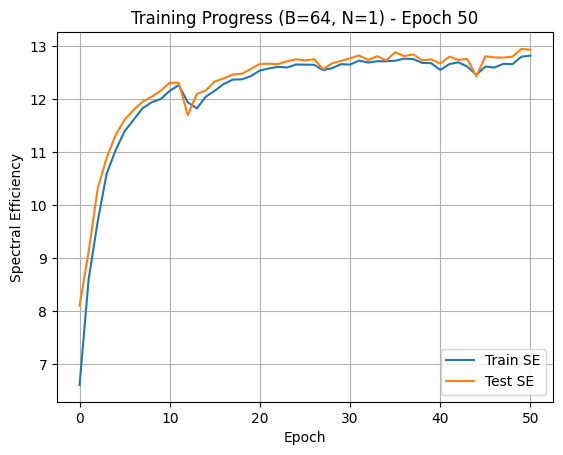

Epoch: 51 | Time: 0:01:11.649834 | Train SE: 12.659 | Test SE: 12.648
Epoch: 52 | Time: 0:01:10.814550 | Train SE: 12.620 | Test SE: 12.740
Epoch: 53 | Time: 0:01:10.464203 | Train SE: 12.693 | Test SE: 12.833
Epoch: 54 | Time: 0:01:10.464731 | Train SE: 12.690 | Test SE: 12.788
Epoch: 55 | Time: 0:01:10.514131 | Train SE: 12.713 | Test SE: 12.879
Epoch: 56 | Time: 0:01:10.299053 | Train SE: 12.745 | Test SE: 12.874
Epoch: 57 | Time: 0:01:10.362176 | Train SE: 12.765 | Test SE: 12.887
Epoch: 58 | Time: 0:01:10.005755 | Train SE: 12.701 | Test SE: 12.839
Epoch: 59 | Time: 0:01:10.329627 | Train SE: 12.770 | Test SE: 12.956
New best model saved with Test SE: 12.9564
Epoch: 60 | Time: 0:01:10.401263 | Train SE: 12.801 | Test SE: 12.888


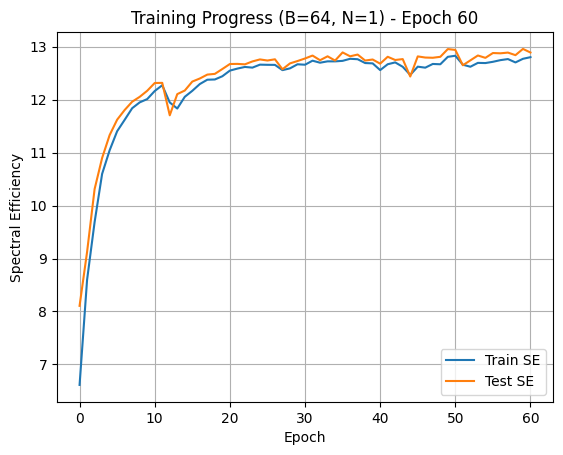

Epoch: 61 | Time: 0:01:10.678831 | Train SE: 12.835 | Test SE: 12.983
New best model saved with Test SE: 12.9832
Epoch: 62 | Time: 0:01:11.082513 | Train SE: 12.848 | Test SE: 12.992
New best model saved with Test SE: 12.9924
Epoch: 63 | Time: 0:01:10.521773 | Train SE: 12.889 | Test SE: 12.994
New best model saved with Test SE: 12.9940
Epoch: 64 | Time: 0:01:10.338696 | Train SE: 12.902 | Test SE: 13.039
New best model saved with Test SE: 13.0389
Epoch: 65 | Time: 0:01:10.566666 | Train SE: 12.915 | Test SE: 13.033
Epoch: 66 | Time: 0:01:10.739441 | Train SE: 12.926 | Test SE: 13.034
Epoch: 67 | Time: 0:01:11.075515 | Train SE: 12.931 | Test SE: 13.031
Epoch: 68 | Time: 0:01:10.653526 | Train SE: 12.918 | Test SE: 13.055
New best model saved with Test SE: 13.0548


In [ ]:
B = 64
train(Nc, N, Nt, B, Nr, L, SNR_dB, K, EPOCH, BATCH_SIZE)